# SEMVR demo

Implementation of equation 5 on page 3 from [this paper](https://proceedings.neurips.cc/paper_files/paper/2018/hash/aba22f748b1a6dff75bda4fd1ee9fe07-Abstract.html). 

### *What I Did*

I implemented the version *I think* is the stochastic EMVR, based on my conversation with Peter and the group.
The steps are almost exactly the same as before for SEM, the only difference being that instead of letting go of the statistics, we store them and keep them in a place where we compute the average score every 100 iteration. After that, we then iterate the average value into consideration.



### *Findings*

So far, what I've found is that *this works sometimes*. In particular, there are settings of the parameters where this algorithm performs very well, in practical time, on large hypergraphs. Here's an example of estimating the parameters on a hypergraph with 1M edges and roughly 1M nodes. 

In [1]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem_vr", "src") # my implementation of baby SEM

from matplotlib import pyplot as plt
import numpy as np

In [2]:
# generate some sample data

eta   = 0.7   # node retention in edges
beta  = 1.2   # poisson number of novel nodes
gamma = 0.8   # poisson number of nodes from graph

timesteps = int(1e6)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

This hypergraph has 1000002 edges and 1198690 nodes.


In [3]:
# initialize a model with 
# initial parameter guesses
EM = sem.SEM_vr(H, pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02})

In [4]:
# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

# main loop
for i in range(steps):

    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
        
        
    EM.SEM_step(0.002) # both the stochastic E and the M steps are in here
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])

--------
Completed step 0
{'eta': 0.3, 'beta': 0.4, 'gamma': 0.02}
--------
Completed step 250
{'eta': 0.4223182824963568, 'beta': 0.6349359815162465, 'gamma': 0.278159455923952}
--------
Completed step 500
{'eta': 0.523838165616753, 'beta': 0.846508598098384, 'gamma': 0.47836414014509365}
--------
Completed step 750
{'eta': 0.588091255752566, 'beta': 1.028356126724934, 'gamma': 0.5896120730155973}
--------
Completed step 1000
{'eta': 0.6284161064556895, 'beta': 1.111546938031807, 'gamma': 0.6778238911001774}
--------
Completed step 1250
{'eta': 0.656483237667221, 'beta': 1.128326869225313, 'gamma': 0.7361210347476418}
--------
Completed step 1500
{'eta': 0.6739133624048257, 'beta': 1.1231002180981873, 'gamma': 0.7506760098687667}
--------
Completed step 1750
{'eta': 0.6850751314231057, 'beta': 1.1466886866451749, 'gamma': 0.7549159929939839}
--------
Completed step 2000
{'eta': 0.6924431388303425, 'beta': 1.165357779947646, 'gamma': 0.7459354960627461}
--------
Completed step 2250
{'e

On a medium-powerful computer (the head node of Middlebury's compute cluster), this took about 8 minutes.  

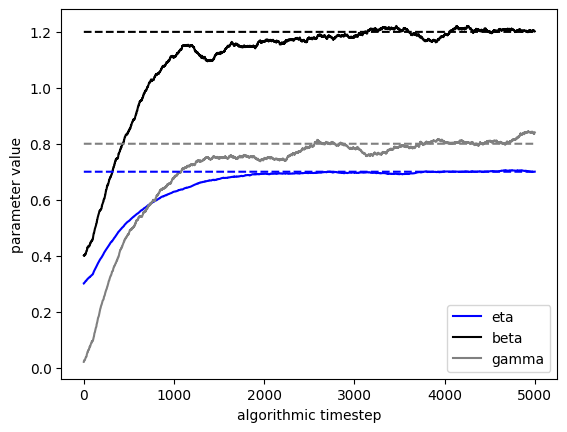

In [5]:
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

That looks pretty promising! 

## Curiously I think I found out reasons why the previous set is not working

This is probably because beta<1. I am not sure why but I think from the point of view of how beta was set up, it is set up as the number of novel nodes, and it is expected to be at least 1 novel node added, and if you set it to be <1, than something will be wrong. 

I tried a couple of different combination with eta and gamma very small or large and beta>1, and they all worked. 

This hypergraph has 10002 edges and 980 nodes.
--------
Completed step 0
{'eta': 0.2997, 'beta': 0.3996, 'gamma': 0.020980000000000002}
--------
Completed step 250
{'eta': 0.26223065182172645, 'beta': 0.30398127375211964, 'gamma': 0.26179573908296194}
--------
Completed step 500
{'eta': 0.22152727497656888, 'beta': 0.21780532955433116, 'gamma': 0.47879817265843316}
--------
Completed step 750
{'eta': 0.2024214480490382, 'beta': 0.1657503367488112, 'gamma': 0.6573156333293634}
--------
Completed step 1000
{'eta': 0.18972352231342404, 'beta': 0.1370601286909162, 'gamma': 0.7442008409954579}
--------
Completed step 1250
{'eta': 0.18023228450029438, 'beta': 0.11439150351315006, 'gamma': 0.7794064825868761}
--------
Completed step 1500
{'eta': 0.1783646965873743, 'beta': 0.11605636414705094, 'gamma': 0.8384771908793661}
--------
Completed step 1750
{'eta': 0.16261918818453058, 'beta': 0.11420925829706553, 'gamma': 0.8368879891277003}
--------
Completed step 2000
{'eta': 0.15358809262586712,

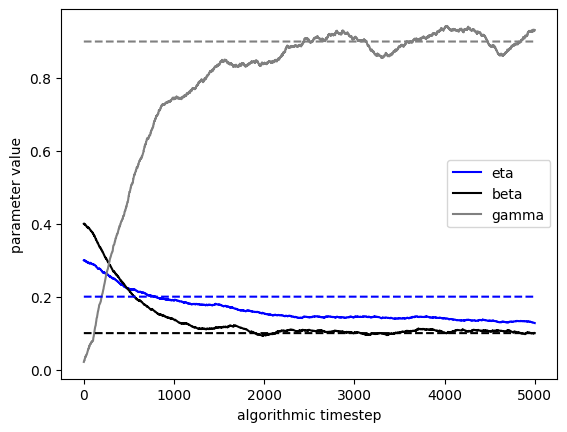

In [7]:
# generate some sample data

eta   = 0.2   # node retention in edges
beta  = 0.1   # poisson number of novel nodes
gamma = 0.9   # poisson number of nodes from graph

timesteps = int(1e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

# initialize a model with 
# initial parameter guesses
EM = sem.SEM_vr(H, pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02})

# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

for i in range(steps):

    EM.SEM_step(0.002) # both the stochastic E and the M steps are in here
    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])
    
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

The estimates for $\beta$ and $\gamma$ look ok, but the estimate for $\eta$ is noticeably lower than it should be. I'm uncertain whether this is a statistical bias in the maximum-likelihood framework, or whether there's some opportunity to actually improve the algorithm in such a way that we fix this issue. 

## What Should We Do Next?

- Implement the variance-reduced version of SEM from Chen et al. so that it's not necessary to worry about the learning rate $\rho$. I think this would involve a modified update and the calculation of an expectation over the entire data set in each epoch, which is considerably more complicated. 
- Speed optimizations!! I made no attempts to make my implementation fast at all, and so I am pretty confidence that it could be improved. Some possibilities include: 
    - Memoizing the edge neighborhood (set of overlapping edges). Currently this is queried fresh each step, but storing it as we build it up could allow for faster queries long-term. 
    - More generally, using XGI in a smarter way for faster edge-set queries? 
    - Better use of numpy and stuff? 
    - Actually, performance profiling, because right now I don't actually know exactly what the bottlenecks are in the algorithm. 
- Can we improve the performance of the algorithm for *all* parameter values? This might involve trying to change the Poisson approximation used in the code, or maybe just understanding whether there is some kind of important bias in maximum-likelihood estimation here that we need to understand better. 

